In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
train_df = pd.read_csv("train.tsv", sep="\t", header=None)
val_df   = pd.read_csv("val.tsv", sep="\t", header=None)
test_df  = pd.read_csv("test.tsv", sep="\t", header=None)

# split my data into labels (first col) and features (rest of cols)
y_train = train_df.iloc[:, 0]
X_train = train_df.iloc[:, 1:]

y_val = val_df.iloc[:, 0]
X_val = val_df.iloc[:, 1:]

y_test = test_df.iloc[:, 0]
X_test = test_df.iloc[:, 1:]

In [4]:
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

In [7]:
# Train
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
print("Training accuracy:", accuracy_score(y_train, train_pred))


# Validate
val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

# Test
test_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))

# print report
print(classification_report(y_test, test_pred))

Training accuracy: 0.9757806244995997
Validation Accuracy: 0.9799839871897518
Test Accuracy: 0.9711769415532426
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1213
         1.0       0.00      0.00      0.00        36

    accuracy                           0.97      1249
   macro avg       0.49      0.50      0.49      1249
weighted avg       0.94      0.97      0.96      1249



c:\Users\audre\Documents\UVA Class Assignments\. spring sem 4\CS 4774 - Machine Learning\proj\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\audre\Documents\UVA Class Assignments\. spring sem 4\CS 4774 - Machine Learning\proj\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\audre\Documents\UVA Class Assignments\. spring sem 4\CS 4774 - Machine Learning\proj\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-de

[[1213    0]
 [  36    0]]


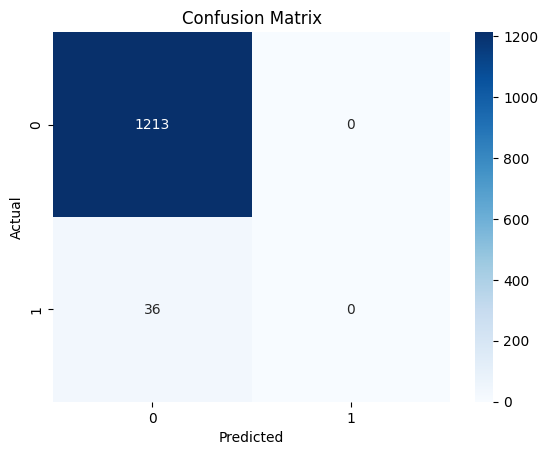

In [14]:
# Confusion matrix format:
# [[TN, FP],
# [FN, TP]]

cm = confusion_matrix(y_test, test_pred)
print(cm)


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()